### Imports

In [1]:
import pandas as pd
import numpy as np
import re
import language_tool_python
from sklearn.metrics import cohen_kappa_score, confusion_matrix, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


from sentence_transformers import SentenceTransformer,util
from sklearn.metrics.pairwise import cosine_similarity


### Loading the data

In [2]:
Sheets=pd.read_excel(r"C:\Users\CompuMarts\OneDrive\Projects\Automated Language Scoring System\Data\Sample Transcriptions for Scoring.xlsx",sheet_name=None)

### Exploratory data analysis

In [3]:
print(len(Sheets))
print(Sheets.keys())

5
dict_keys(['Info', '38001-1A', '38002-2A', '38004-2A', '38006-2A'])


In [4]:
for sheet_name, df in Sheets.items():
    display(sheet_name,df.head())

'Info'

,Unnamed: 0,Unnamed: 1
0,NaN,This file contains 4 sample transcribed EITs t...
1,NaN,"Each sentence should be assigned a score of 0,..."
2,NaN,NaN
3,NaN,All files are EIT vA (same stimuli)


'38001-1A'

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa (7),El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,NaN
3,4,El se ducha cada mañana (9),El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,NaN


'38002-2A'

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa (7),El libro está en la mesa.,NaN
2,3,El carro lo tiene Pedro (8),El carro tiene pelo.,NaN
3,4,El se ducha cada mañana (9),él se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),en que ustedes x uf x hacer hoy?,NaN


'38004-2A'

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa (7),El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro (8),El carro tiene Pedro,NaN
3,4,El se ducha cada mañana (9),El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),¿Qué dices usted vas hacer hoy?,NaN


'38006-2A'

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,NaN
1,2,El libro está en la mesa (7),El libro [pause] está en la mesa,NaN
2,3,El carro lo tiene Pedro (8),E-[gibberish] perro,NaN
3,4,El se ducha cada mañana (9),El se lucha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,NaN


In [5]:
# Checking for null values in each sheet and displaying rows with null values
pd.set_option("display.max_colwidth", None)
for sheet_name, df in Sheets.items():
    print("Sheet:", sheet_name)
    print("Nulls:\n",df.isnull().sum())
    display(df[df.isnull().any(axis=1)])
    print("-"*108)
    

Sheet: Info
Nulls:
 Unnamed: 0    4
Unnamed: 1    1
dtype: int64


,Unnamed: 0,Unnamed: 1
0,NaN,This file contains 4 sample transcribed EITs to be scored using the EIT scoring rubric.
1,NaN,"Each sentence should be assigned a score of 0, 1, 2, 3, or 4"
2,NaN,NaN
3,NaN,All files are EIT vA (same stimuli)


------------------------------------------------------------------------------------------------------------
Sheet: 38001-1A
Nulls:
 Sentence                  0
Stimulus                  0
Transcription Rater 1     0
Score                    30
dtype: int64


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa (7),El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro (8),El carro lo tiene Pedro,NaN
3,4,El se ducha cada mañana (9),El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),Que dices ustedes se que van a hacer hoy?,NaN
5,6,Dudo que sepa manejar muy bien (10),Dudo que sepa manajar bien,NaN
6,7,Las calles de esta ciudad son muy anchas (11),Las calles de esta cuidad son muy anchas,NaN
7,8,Puede que llueva mañana todo el día (12),Puede que lleva mañana todo el día,NaN
8,9,Las casas son muy bonitas pero caras (12),Las casas son muy bonitas pero muy cadas,NaN
9,10,Me gustan las películas que acaban bien (12),Me gustan las peliculas que acaban bien,NaN


------------------------------------------------------------------------------------------------------------
Sheet: 38002-2A
Nulls:
 Sentence                  0
Stimulus                  0
Transcription Rater 1     0
Score                    30
dtype: int64


...

------------------------------------------------------------------------------------------------------------
Sheet: 38004-2A
Nulls:
 Sentence                  0
Stimulus                  0
Transcription Rater 1     0
Score                    30
dtype: int64


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa (7),El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro (8),El carro tiene Pedro,NaN
3,4,El se ducha cada mañana (9),El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),¿Qué dices usted vas hacer hoy?,NaN
5,6,Dudo que sepa manejar muy bien (10),Dudo que sepa manejar muy bien,NaN
6,7,Las calles de esta ciudad son muy anchas (11),Las calles de esta ciudad es muy anchas,NaN
7,8,Puede que llueva mañana todo el día (12),Pueda que llueva mañana todo día,NaN
8,9,Las casas son muy bonitas pero caras (12),Las casas son muy bonitas para caras,NaN
9,10,Me gustan las películas que acaban bien (12),Mis gus..Me gustas las películas que cada bien,NaN


------------------------------------------------------------------------------------------------------------
Sheet: 38006-2A
Nulls:
 Sentence                  0
Stimulus                  0
Transcription Rater 1     0
Score                    30
dtype: int64


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,NaN
1,2,El libro está en la mesa (7),El libro [pause] está en la mesa,NaN
2,3,El carro lo tiene Pedro (8),E-[gibberish] perro,NaN
3,4,El se ducha cada mañana (9),El se lucha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,NaN
5,6,Dudo que sepa manejar muy bien (10),Dudo que sepa ma-mastar tan bien (tambien?),NaN
6,7,Las calles de esta ciudad son muy anchas (11),Las calles..es-[gibberish]...,NaN
7,8,Puede que llueva mañana todo el día (12),Puede xxx mañana de todo día,NaN
8,9,Las casas son muy bonitas pero caras (12),A las casa es mu-son bonitas,NaN
9,10,Me gustan las películas que acaban bien (12),Me gusta las películas que x bien,NaN


------------------------------------------------------------------------------------------------------------


### Data Cleaning

In [6]:
#removing unecessary sheet
del Sheets['Info']
Sheets.keys()

dict_keys(['38001-1A', '38002-2A', '38004-2A', '38006-2A'])

In [7]:
# Removing annotations from "Stimulus" and "Transcription Rater 1" columns to avoid interference with scoring
for sheet_name,df in Sheets.items():
    df["Stimulus"] = df["Stimulus"].str.replace(r"\(.*?\)", "", regex=True)
    df["Transcription Rater 1"]=df["Transcription Rater 1"].str.replace(r"\[.*?\]","",regex=True)
    display(df.head(15))    

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa,El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro,El carro lo tiene Pedro,NaN
3,4,El se ducha cada mañana,El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy?,Que dices ustedes se que van a hacer hoy?,NaN
5,6,Dudo que sepa manejar muy bien,Dudo que sepa manajar bien,NaN
6,7,Las calles de esta ciudad son muy anchas,Las calles de esta cuidad son muy anchas,NaN
7,8,Puede que llueva mañana todo el día,Puede que lleva mañana todo el día,NaN
8,9,Las casas son muy bonitas pero caras,Las casas son muy bonitas pero muy cadas,NaN
9,10,Me gustan las películas que acaban bien,Me gustan las peliculas que acaban bien,NaN


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa,El libro está en la mesa.,NaN
2,3,El carro lo tiene Pedro,El carro tiene pelo.,NaN
3,4,El se ducha cada mañana,él se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy?,en que ustedes x uf x hacer hoy?,NaN
5,6,Dudo que sepa manejar muy bien,dudo/tu no? sepiar exx muy bien,NaN
6,7,Las calles de esta ciudad son muy anchas,La calles estén xxxx muy anchas.,NaN
7,8,Puede que llueva mañana todo el día,Puede que mañana todo la día,NaN
8,9,Las casas son muy bonitas pero caras,Las casas muy bonitos pero ... casas,NaN
9,10,Me gustan las películas que acaban bien,Me gustan las películas campan bien,NaN


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa,El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro,El carro tiene Pedro,NaN
3,4,El se ducha cada mañana,El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué dices usted vas hacer hoy?,NaN
5,6,Dudo que sepa manejar muy bien,Dudo que sepa manejar muy bien,NaN
6,7,Las calles de esta ciudad son muy anchas,Las calles de esta ciudad es muy anchas,NaN
7,8,Puede que llueva mañana todo el día,Pueda que llueva mañana todo día,NaN
8,9,Las casas son muy bonitas pero caras,Las casas son muy bonitas para caras,NaN
9,10,Me gustan las películas que acaban bien,Mis gus..Me gustas las películas que cada bien,NaN


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme mi pelo,NaN
1,2,El libro está en la mesa,El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro,E- perro,NaN
3,4,El se ducha cada mañana,El se lucha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué que vas estoy?,NaN
5,6,Dudo que sepa manejar muy bien,Dudo que sepa ma-mastar tan bien (tambien?),NaN
6,7,Las calles de esta ciudad son muy anchas,Las calles..es-...,NaN
7,8,Puede que llueva mañana todo el día,Puede xxx mañana de todo día,NaN
8,9,Las casas son muy bonitas pero caras,A las casa es mu-son bonitas,NaN
9,10,Me gustan las películas que acaban bien,Me gusta las películas que x bien,NaN


### Initializing Model & Grammar Tool


In [8]:
# Initialize the sentence transformer model
model = SentenceTransformer("all-MiniLM-L6-v2")
lang_tool = language_tool_python.LanguageTool('es')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Essential Intermediate Analysis Before Final Scoring

In [9]:
# Function to compute similarity score and grammar error count for a given response in comparison with its stimulus
def Scoring_trial(stimulus,response):
    stim_vec=model.encode(stimulus,convert_to_tensor=True)
    resp_vec=model.encode(response,convert_to_numpy=True)
    similarity_score=util.cos_sim(stim_vec,resp_vec)
    errors = lang_tool.check(response)
    error_count = len(errors)
    return similarity_score.item(),error_count

In [10]:
# Inserting a sample score column to have an already marked samplefor comparing it with model results of similarity and grammar error count.
# so that we can tune the thresholds in the final scoring function to get reliable results. 
import copy
ManualScoringSheet = copy.deepcopy(Sheets)

# These scores are used as a proxy for evaluation in the absence of official annotations.
sample_scores_set1 = [4,4,3,4,2,4,3,3,3,2,1,3,2,1,2,3,1,2,1,2,2,1,1,1,2,2,2,1,0,2]
sample_scores_set2 = [3,4,1,2,1,1,1,1,1,2,1,2,1,2,1,0,2,3,0,3,2,1,1,1,1,1,1,1,2,1]
for sheetName,df_m in ManualScoringSheet.items():
    if sheetName == "38004-2A":
        df_m["Sample Score"] = sample_scores_set1
    elif sheetName == "38006-2A":
        df_m["Sample Score"] = sample_scores_set2
    display(df_m.head())

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa,El libro está en la mesa,NaN
2,3,El carro lo tiene Pedro,El carro lo tiene Pedro,NaN
3,4,El se ducha cada mañana,El se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy?,Que dices ustedes se que van a hacer hoy?,NaN


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,NaN
1,2,El libro está en la mesa,El libro está en la mesa.,NaN
2,3,El carro lo tiene Pedro,El carro tiene pelo.,NaN
3,4,El se ducha cada mañana,él se ducha cada mañana,NaN
4,5,¿Qué dice usted que va a hacer hoy?,en que ustedes x uf x hacer hoy?,NaN


,Sentence,Stimulus,Transcription Rater 1,Score,Sample Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,NaN,4
1,2,El libro está en la mesa,El libro está en la mesa,NaN,4
2,3,El carro lo tiene Pedro,El carro tiene Pedro,NaN,3
3,4,El se ducha cada mañana,El se ducha cada mañana,NaN,4
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué dices usted vas hacer hoy?,NaN,2


,Sentence,Stimulus,Transcription Rater 1,Score,Sample Score
0,1,Quiero cortarme el pelo,Quiero cortarme mi pelo,NaN,3
1,2,El libro está en la mesa,El libro está en la mesa,NaN,4
2,3,El carro lo tiene Pedro,E- perro,NaN,1
3,4,El se ducha cada mañana,El se lucha cada mañana,NaN,2
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué que vas estoy?,NaN,1


In [11]:
# Computing similarity scores and grammar error counts for each response in the two sheets and adding them as new columns
temp1=ManualScoringSheet["38004-2A"]
temp2=ManualScoringSheet["38006-2A"]
for df in [temp1, temp2]:
    scores = []
    error_counts=[]
    for idx, row in df.iterrows():
        stim = row["Stimulus"]
        resp = row["Transcription Rater 1"]
        result = Scoring_trial(stim, resp)
        scores.append(result[0])
        error_counts.append(result[1])
    df["Similarity Score"] = scores
    df["Grammatical Errors Count"] = error_counts
display(temp1.head())
display(temp2.head())    


,Sentence,Stimulus,Transcription Rater 1,Score,Sample Score,Similarity Score,Grammatical Errors Count
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,NaN,4,1.000000,0
1,2,El libro está en la mesa,El libro está en la mesa,NaN,4,1.000000,0
2,3,El carro lo tiene Pedro,El carro tiene Pedro,NaN,3,0.981937,0
3,4,El se ducha cada mañana,El se ducha cada mañana,NaN,4,1.000000,1
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué dices usted vas hacer hoy?,NaN,2,0.939238,1


,Sentence,Stimulus,Transcription Rater 1,Score,Sample Score,Similarity Score,Grammatical Errors Count
0,1,Quiero cortarme el pelo,Quiero cortarme mi pelo,NaN,3,0.884712,0
1,2,El libro está en la mesa,El libro está en la mesa,NaN,4,1.000000,1
2,3,El carro lo tiene Pedro,E- perro,NaN,1,0.237944,0
3,4,El se ducha cada mañana,El se lucha cada mañana,NaN,2,0.847205,1
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué que vas estoy?,NaN,1,0.768038,1


### Threshold Analysis

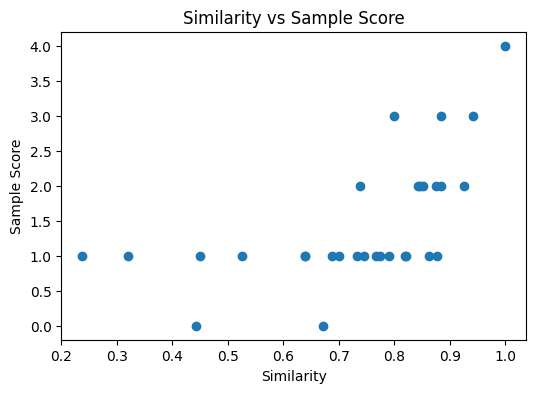

In [12]:
#visualizing the relationship between similarity scores and sample scores using a scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df["Similarity Score"], df["Sample Score"])
plt.xlabel("Similarity")
plt.ylabel("Sample Score")
plt.title("Similarity vs Sample Score")
plt.savefig("Plots_results/similarity_vs_sample_score.png")
plt.show()

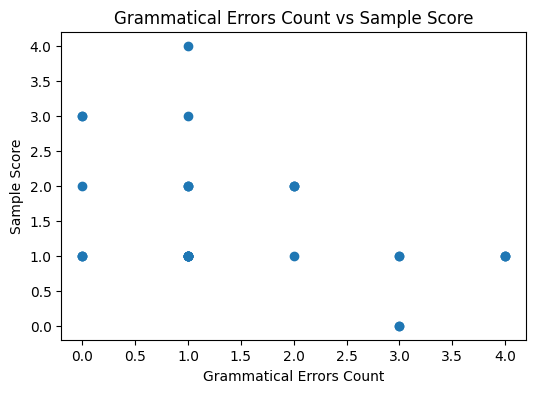

In [13]:
#visualizing the relationship between grammatical error counts and sample scores using a scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df["Grammatical Errors Count"], df["Sample Score"])
plt.xlabel("Grammatical Errors Count")
plt.ylabel("Sample Score")
plt.title("Grammatical Errors Count vs Sample Score")
plt.savefig("Plots_results/grammatical_errors_count_vs_sample_score.png")
plt.show()

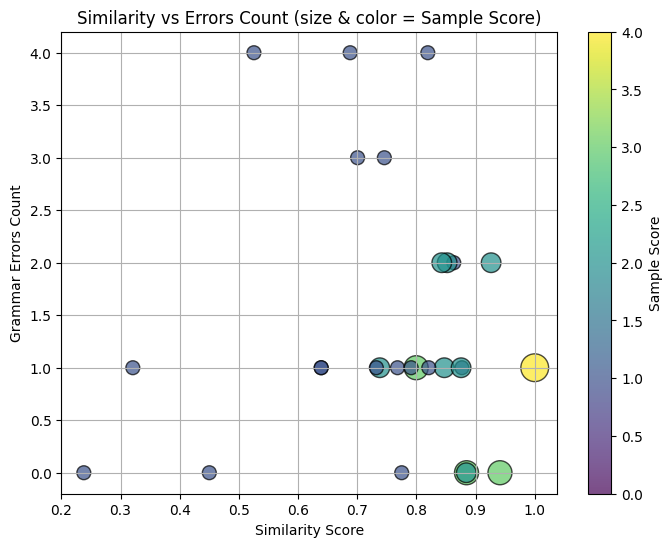

In [14]:
#visualizing the relationship between similarity scores, grammatical error counts and
#  sample scores using a scatter plot with color and size encoding
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df["Similarity Score"], 
    df["Grammatical Errors Count"], 
    c=df["Sample Score"], 
    s=np.array(df["Sample Score"])*100,  # bigger dots for higher sample score
    cmap="viridis", 
    alpha=0.7,  # semi-transparent to see overlapping points
    edgecolors='k'  # black border for better separation
)
plt.xlabel("Similarity Score")
plt.ylabel("Grammar Errors Count")
plt.title("Similarity vs Errors Count (size & color = Sample Score)")
plt.colorbar(scatter, label="Sample Score")
plt.grid(True)
plt.savefig("Plots_results/similarity_vs_errors_count_sample_score.png")
plt.show()

### Preprocessing

In [15]:
# Final scoring function that combines similarity score and grammar error count to
#  assign a final score from 0 to 4 based on defined thresholds 
# The thresholds can be tuned based on the distribution of similarity scores and 
# grammatical error counts with the sample scores to achieve better alignment with
#  the sample scores that follow the rubric applied.

def Scoring(stimulus,response):
    stim_vec=model.encode(stimulus,convert_to_tensor=True)
    resp_vec=model.encode(response,convert_to_tensor=True)
    similarity_score=util.cos_sim(stim_vec,resp_vec).item() # cosine similarity between stimulus and response
   
    errors = lang_tool.check(response)
    error_count = len(errors)
    if similarity_score > 0.98 and error_count <= 1:
        return 4
    if similarity_score >= 0.70 and error_count <= 0:
        return 3
    if similarity_score > 0.5 and error_count <= 2:
        return 2
    if similarity_score >= 0.3 and error_count <= 4:
        return 1
    return 0
    

In [16]:
# Applying the final scoring function to each response in 
# the sheets and adding the final scores as a new column "Score".
for df in Sheets.values():
    scores = []
    for idx, row in df.iterrows():
        stim = row["Stimulus"]
        resp = row["Transcription Rater 1"]
        score = Scoring(stim, resp)
        scores.append(score)
    df["Score"] = scores
    display(df.head(10))


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,4
1,2,El libro está en la mesa,El libro está en la mesa,4
2,3,El carro lo tiene Pedro,El carro lo tiene Pedro,4
3,4,El se ducha cada mañana,El se ducha cada mañana,4
4,5,¿Qué dice usted que va a hacer hoy?,Que dices ustedes se que van a hacer hoy?,2
5,6,Dudo que sepa manejar muy bien,Dudo que sepa manajar bien,2
6,7,Las calles de esta ciudad son muy anchas,Las calles de esta cuidad son muy anchas,2
7,8,Puede que llueva mañana todo el día,Puede que lleva mañana todo el día,3
8,9,Las casas son muy bonitas pero caras,Las casas son muy bonitas pero muy cadas,2
9,10,Me gustan las películas que acaban bien,Me gustan las peliculas que acaban bien,4


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,4
1,2,El libro está en la mesa,El libro está en la mesa.,4
2,3,El carro lo tiene Pedro,El carro tiene pelo.,3
3,4,El se ducha cada mañana,él se ducha cada mañana,4
4,5,¿Qué dice usted que va a hacer hoy?,en que ustedes x uf x hacer hoy?,1
5,6,Dudo que sepa manejar muy bien,dudo/tu no? sepiar exx muy bien,1
6,7,Las calles de esta ciudad son muy anchas,La calles estén xxxx muy anchas.,2
7,8,Puede que llueva mañana todo el día,Puede que mañana todo la día,2
8,9,Las casas son muy bonitas pero caras,Las casas muy bonitos pero ... casas,2
9,10,Me gustan las películas que acaban bien,Me gustan las películas campan bien,3


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,4
1,2,El libro está en la mesa,El libro está en la mesa,4
2,3,El carro lo tiene Pedro,El carro tiene Pedro,4
3,4,El se ducha cada mañana,El se ducha cada mañana,4
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué dices usted vas hacer hoy?,2
5,6,Dudo que sepa manejar muy bien,Dudo que sepa manejar muy bien,4
6,7,Las calles de esta ciudad son muy anchas,Las calles de esta ciudad es muy anchas,3
7,8,Puede que llueva mañana todo el día,Pueda que llueva mañana todo día,3
8,9,Las casas son muy bonitas pero caras,Las casas son muy bonitas para caras,3
9,10,Me gustan las películas que acaban bien,Mis gus..Me gustas las películas que cada bien,2


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme mi pelo,3
1,2,El libro está en la mesa,El libro está en la mesa,4
2,3,El carro lo tiene Pedro,E- perro,0
3,4,El se ducha cada mañana,El se lucha cada mañana,2
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué que vas estoy?,2
5,6,Dudo que sepa manejar muy bien,Dudo que sepa ma-mastar tan bien (tambien?),1
6,7,Las calles de esta ciudad son muy anchas,Las calles..es-...,2
7,8,Puede que llueva mañana todo el día,Puede xxx mañana de todo día,3
8,9,Las casas son muy bonitas pero caras,A las casa es mu-son bonitas,2
9,10,Me gustan las películas que acaban bien,Me gusta las películas que x bien,2


# Evaluating Final Results

In [17]:
# Evaluation function to compare model scores with sample scores using various metrics and visualizations
#  to assess the performance of the scoring function and identify areas for improvement.
def evaluate_scores(df, label="Sheet_name"):
    sample = df["Sample Score"].values
    model = df["Model Score"].values
    
    # Exact Accuracy
    exact_acc = np.mean(sample == model)
    
    # ±1 Tolerance Accuracy
    tolerance_acc = np.mean(np.abs(sample - model) <= 1)
    
    # Mean Absolute Error
    mae = mean_absolute_error(sample, model) 
    
    # Cohen's Kappa 
    kappa = cohen_kappa_score(sample, model, weights="quadratic")
   
    
    print(f"--- {label} Evaluation")
    print(f"Exact Accuracy      : {exact_acc*100:.2f}%")
    print(f"±1 Tolerance Acc    : {tolerance_acc*100:.2f}%")
    print(f"Mean Absolute Error : {mae:.2f}")
    print(f"Cohen's Kappa       : {kappa:.2f}")
    
    # Confusion Matrix
    cm = confusion_matrix(sample, model, labels=[0,1,2,3,4])
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    plt.xlabel("Model Score")
    plt.ylabel("Sample Score")
    plt.title(f"{label} Confusion Matrix")
    plt.savefig(f"Plots_results/{label}_confusion_matrix.png")
    plt.show()
    
    # Scatter Plot
    plt.figure(figsize=(6,4))
    plt.scatter(sample, model, alpha=0.7)
    plt.plot([0,4],[0,4], color='red', linestyle='--')  # ideal line
    plt.xticks([0,1,2,3,4])
    plt.yticks([0,1,2,3,4])
    plt.xlabel("Sample Score")
    plt.ylabel("Model Score")
    plt.title(f"{label} Scatter Plot")
    plt.savefig(f"Plots_results/{label}_scatter_plot.png")
    plt.show()


In [18]:
for sheet_name, df in Sheets.items():
    display(df.head())

,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,4
1,2,El libro está en la mesa,El libro está en la mesa,4
2,3,El carro lo tiene Pedro,El carro lo tiene Pedro,4
3,4,El se ducha cada mañana,El se ducha cada mañana,4
4,5,¿Qué dice usted que va a hacer hoy?,Que dices ustedes se que van a hacer hoy?,2


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,4
1,2,El libro está en la mesa,El libro está en la mesa.,4
2,3,El carro lo tiene Pedro,El carro tiene pelo.,3
3,4,El se ducha cada mañana,él se ducha cada mañana,4
4,5,¿Qué dice usted que va a hacer hoy?,en que ustedes x uf x hacer hoy?,1


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme el pelo,4
1,2,El libro está en la mesa,El libro está en la mesa,4
2,3,El carro lo tiene Pedro,El carro tiene Pedro,4
3,4,El se ducha cada mañana,El se ducha cada mañana,4
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué dices usted vas hacer hoy?,2


,Sentence,Stimulus,Transcription Rater 1,Score
0,1,Quiero cortarme el pelo,Quiero cortarme mi pelo,3
1,2,El libro está en la mesa,El libro está en la mesa,4
2,3,El carro lo tiene Pedro,E- perro,0
3,4,El se ducha cada mañana,El se lucha cada mañana,2
4,5,¿Qué dice usted que va a hacer hoy?,¿Qué que vas estoy?,2


--- 38004-2A Evaluation
Exact Accuracy      : 60.00%
±1 Tolerance Acc    : 93.33%
Mean Absolute Error : 0.47
Cohen's Kappa       : 0.71


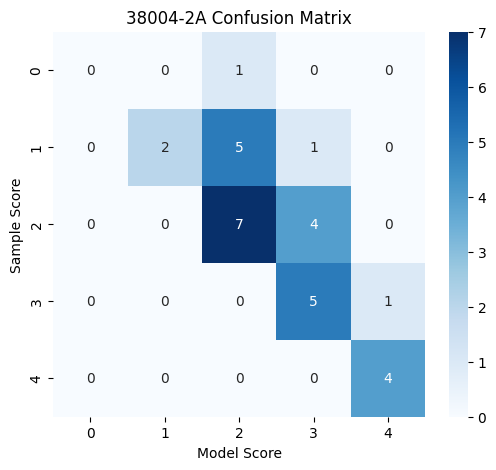

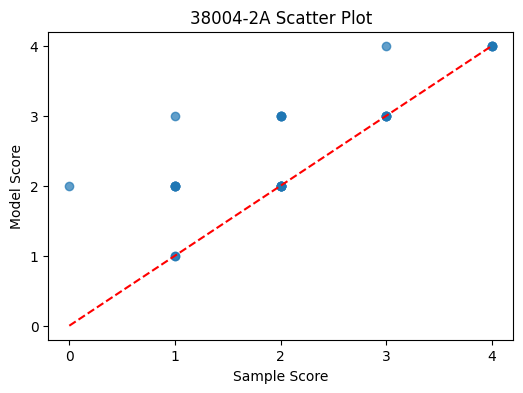

--- 38006-2A Evaluation
Exact Accuracy      : 53.33%
±1 Tolerance Acc    : 96.67%
Mean Absolute Error : 0.50
Cohen's Kappa       : 0.64


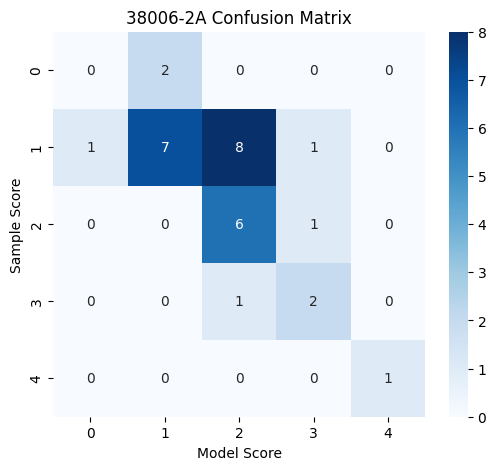

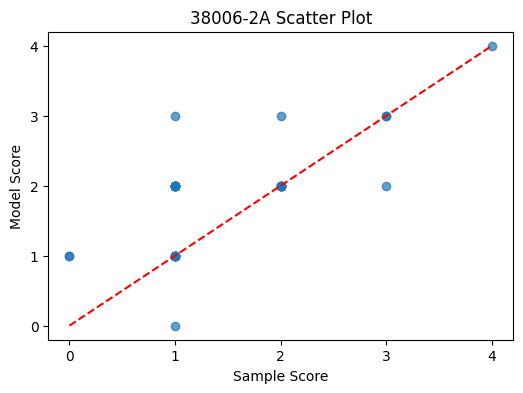

In [19]:
# Assigning the computed model scores to the ManualScoringSheet for evaluation against the sample scores.
ManualScoringSheet["38004-2A"]["Model Score"]=copy.deepcopy(Sheets["38004-2A"]["Score"].values)
ManualScoringSheet["38006-2A"]["Model Score"]=copy.deepcopy(Sheets["38006-2A"]["Score"].values)
evaluate_scores(ManualScoringSheet["38004-2A"], label="38004-2A")
evaluate_scores(ManualScoringSheet["38006-2A"], label="38006-2A")

### Saving Data

In [20]:
file_path = "Data Outputs/Transcriptions_Scored_By_Sondos.xlsx"
for sheet_name, df in Sheets.items():
     df.to_excel(file_path, sheet_name=sheet_name, index=False)
     print(f"Data saved successfully to {file_path}")

Data saved successfully to Data Outputs/Transcriptions_Scored_By_Sondos.xlsx
Data saved successfully to Data Outputs/Transcriptions_Scored_By_Sondos.xlsx
Data saved successfully to Data Outputs/Transcriptions_Scored_By_Sondos.xlsx
Data saved successfully to Data Outputs/Transcriptions_Scored_By_Sondos.xlsx


##                                       .------------------------------Code Ended---------------------------.